# Image Colorization — U-Net

**Pipeline:** grayscale → U-Net → RGB  
**Dataset:**  (COCO, ImageNet, etc.)  
**Loss:** MSELoss    NOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOO

---

## 0. IMPORTS

In [1]:
import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

# The Ultimate Hardware Detector
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("🚀 NVIDIA GPU Detected! Using CUDA.")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🍏 Apple Silicon Detected! Using MPS.")
else:
    try:
        import torch_directml
        if torch_directml.is_available():
            device = torch_directml.device()
            print("🎮 AMD/Windows GPU Detected! Using DirectML.")
        else:
            raise ImportError
    except ImportError:
        device = torch.device("cpu")
        print("🐌 No recognized GPU found. Falling back to CPU. (This will be slow!)")

🎮 AMD/Windows GPU Detected! Using DirectML.


## 1. Dataset

In [ ]:
class ColorizationDataset(Dataset):
    """
    Reads RGB images from a folder.
    Returns (grayscale [1,H,W], color [3,H,W]) in the range [0, 1].
    """
    def __init__(self, root_dir: str, size: int = 128, limit: int = None):
        exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        paths = [
            f for f in os.listdir(root_dir)
            if os.path.splitext(f)[1].lower() in exts
        ]
        if limit:
            paths = paths[:limit]
        self.paths = [os.path.join(root_dir, p) for p in paths]

        self.tf = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img   = Image.open(self.paths[idx]).convert("RGB")
        color = self.tf(img)
        gray  = transforms.functional.rgb_to_grayscale(color)
        return gray, color

## 2. DataLoader

In [ ]:
ROOT_DIR = "data/images"   
IMG_SIZE = 128
LIMIT    = 2000 # CHANGE THIS 
BATCH    = 32
NUM_OF_WORKERS = 0 # CHANGE THIS




dataset = ColorizationDataset(root_dir=ROOT_DIR, size=IMG_SIZE, limit=LIMIT)

loader = DataLoader(
    dataset,
    batch_size=BATCH,
    shuffle=True,
    num_workers=NUM_OF_WORKERS,
    pin_memory=(device.type == "cuda"),
)
print(f"Images  : {len(dataset)}")
print(f"Batches : {len(loader)}")

Images  : 2000
Batches : 63


## 3. check one example

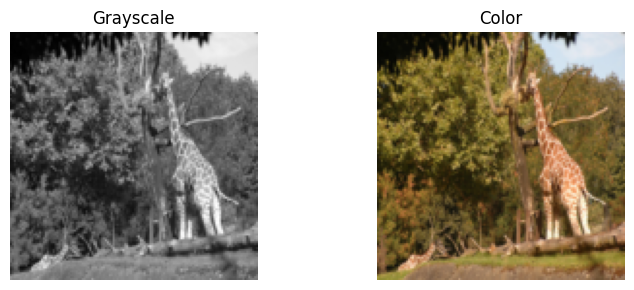

In [ ]:
gray, color = dataset[0]

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(gray.squeeze(), cmap="gray"); axes[0].set_title("Grayscale")
axes[1].imshow(color.permute(1, 2, 0));      axes[1].set_title("Color")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

## 4.  MODEL — U-Net



In [ ]:
def conv_block(in_c: int, out_c: int) -> nn.Sequential:
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
        nn.Conv2d(out_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
    )


class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc1 = conv_block(1,   64)
        self.enc2 = conv_block(64, 128)
        self.pool = nn.MaxPool2d(2)
        # Bottleneck
        self.mid  = conv_block(128, 256)
        # Decoder
        self.up2  = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2 = conv_block(256, 128)   # 128 skip + 128 up
        self.up1  = nn.ConvTranspose2d(128,  64, 2, 2)
        self.dec1 = conv_block(128,  64)   #  64 skip +  64 up
        # Output
        self.out  = nn.Conv2d(64, 3, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        m  = self.mid(self.pool(e2))
        d2 = self.dec2(torch.cat([self.up2(m),  e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return torch.sigmoid(self.out(d1))


model = UNet().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"PARAMETERS: {total_params:,}")

PARAMETERS: 1,861,827


## 5. Learning

In [ ]:
EPOCHS = 5
LR     = 1e-3

criterion = nn.L1Loss()  #    before was  criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0

    for gray, color in loader:
        gray, color = gray.to(device), color.to(device)
        pred = model(gray)
        loss = criterion(pred, color)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running += loss.item()

    avg = running / len(loader)
    history.append(avg)
    print(f"Epoch {epoch}/{EPOCHS}  loss={avg:.4f}")

torch.save(model.state_dict(), "unet_colorization.pth")
print("\nMODEL SAVED → unet_colorization.pth")

Epoch 1/5  loss=0.0610
Epoch 2/5  loss=0.0533
Epoch 3/5  loss=0.0527
Epoch 4/5  loss=0.0525
Epoch 5/5  loss=0.0523

MODEL SAVED → unet_colorization.pth


## 6. The graph of model

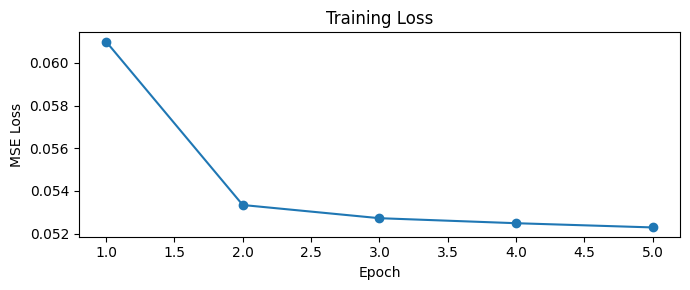

In [ ]:
plt.figure(figsize=(7, 3))
plt.plot(range(1, EPOCHS + 1), history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.tight_layout()
plt.show()


## 7. vizualing model

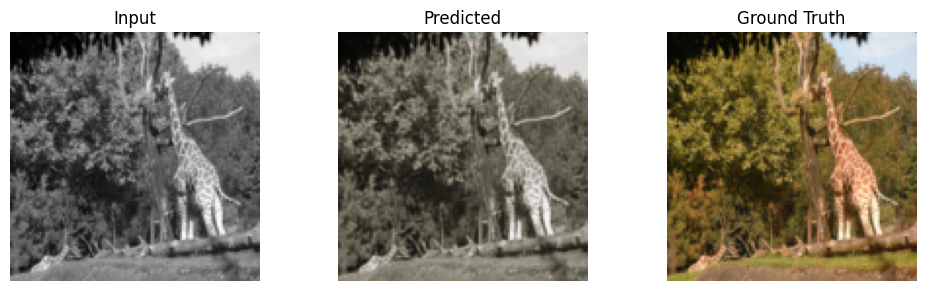

saved → result.png


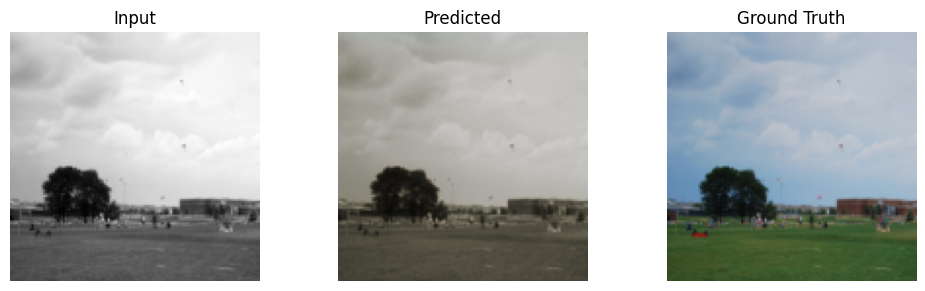

saved → result.png


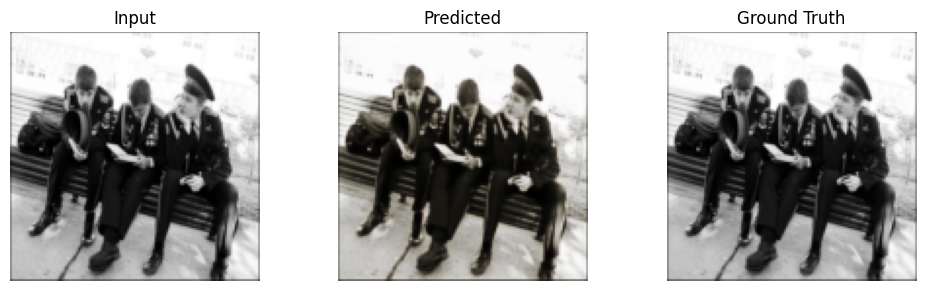

saved → result.png


In [ ]:
def visualize(model: nn.Module, dataset: ColorizationDataset, idx: int = 0):
    model.eval()
    gray, color = dataset[idx]

    with torch.no_grad():
        pred = model(gray.unsqueeze(0).to(device)).squeeze().cpu()

    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    axes[0].imshow(gray.squeeze(),          cmap="gray"); axes[0].set_title("Input")
    axes[1].imshow(pred.permute(1, 2, 0));               axes[1].set_title("Predicted")
    axes[2].imshow(color.permute(1, 2, 0));              axes[2].set_title("Ground Truth")
    for ax in axes: ax.axis("off")
    plt.tight_layout()
    plt.savefig("result.png", dpi=120)
    plt.show()
    print("saved → result.png")


for i in [0, 5, 10]:
    visualize(model, dataset, idx=i)

## 8. LOADING SAVE MODEL

In [ ]:
# model = UNet().to(device)
# model.load_state_dict(torch.load("unet_colorization.pth", map_location=device))
# model.eval()
# print("model downloaded")